         Graph         Library  Iteration  Mean_ms  Median_ms  CI_lower  \
0  patents.mtx  LAGraph-Normal          1    1.436      1.436     1.436   
1  patents.mtx  LAGraph-Normal          2    1.496      1.496     1.496   
2  patents.mtx  LAGraph-Normal          3    1.459      1.459     1.459   
3  patents.mtx  LAGraph-Normal          4    1.474      1.474     1.474   
4  patents.mtx  LAGraph-Normal          5    1.435      1.435     1.435   

   CI_upper  Std_Err  P_Normal  Sample_Size      GTEPS  
0     1.436      0.0       NaN          1.0  11.502383  
1     1.496      0.0       NaN          1.0  11.041057  
2     1.459      0.0       NaN          1.0  11.321057  
3     1.474      0.0       NaN          1.0  11.205849  
4     1.435      0.0       NaN          1.0  11.510399  


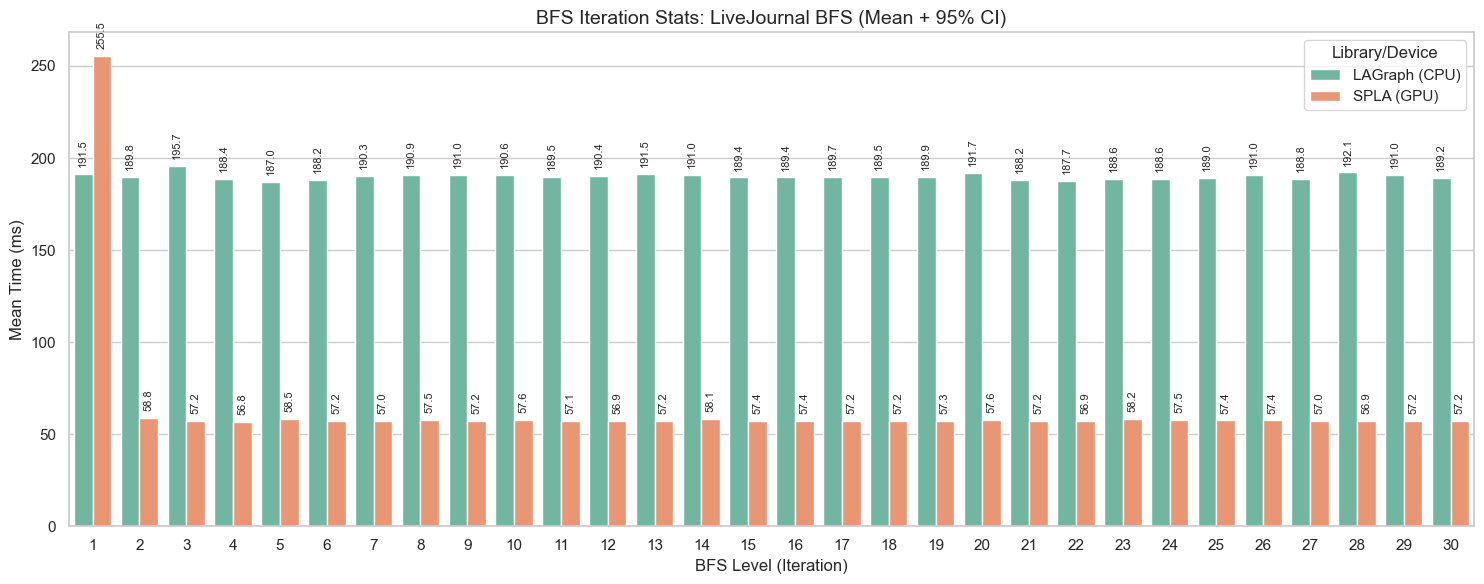

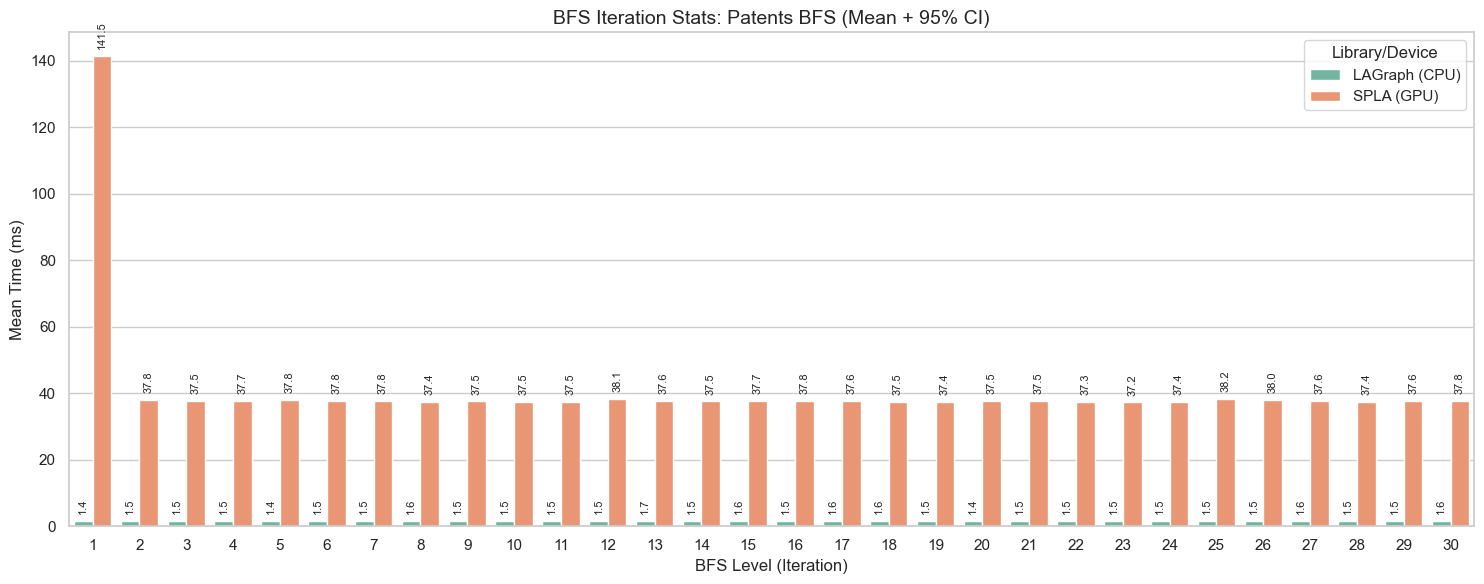

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Данные о графах (для GTEPS)
# В BFS GTEPS обычно считается как (сумма ребер в текущем фронтире) / время.
# Здесь используем общее кол-во ребер для оценки средней производительности шага.
graph_info = {
    'soc-LiveJournal1.mtx': {'edges': 68993773, 'desc': 'Social'},
    'patents.mtx': {'edges': 16517422, 'desc': 'Patents'}
}

# 2. Функция для расчета статистики (как в ПГ)
def get_stats(group):
    data = group['Time_ms']
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data) if n > 1 else 0
    
    p_val = stats.shapiro(data)[1] if n >= 3 else np.nan
    
    if n > 1:
        ci = stats.t.interval(0.95, n-1, loc=mean, scale=std_err)
    else:
        ci = (mean, mean)
        
    return pd.Series({
        'Mean_ms': mean,
        'Median_ms': np.median(data),
        'CI_lower': ci[0],
        'CI_upper': ci[1],
        'Std_Err': std_err,
        'P_Normal': p_val,
        'Sample_Size': n
    })

# 3. Загрузка и предобработка
df_bfs = pd.read_csv('../../results/bfs/results.csv')
df_bfs['Iteration'] = df_bfs['Iteration'].astype(int)
df_bfs['Time_ms'] = df_bfs['Time_ms'].astype(float)

# Очистка данных: убираем JIT (первый запуск первого шага SPLA)
# Если в вашем CSV несколько запусков (Runs), мы группируем по итерациям.
df_clean = df_bfs[~((df_bfs['Library'] == 'SPLA') & (df_bfs['Iteration'] == 1) & (df_bfs['Time_ms'] > df_bfs['Time_ms'].mean()*5))].copy()

# 4. Аггрегация статистики по каждой итерации (уровню) каждого графа
# Группируем по Графу, Библиотеке и Номеру итерации
df_stats = df_clean.groupby(['Graph', 'Library', 'Iteration']).apply(get_stats).reset_index()

# 5. Расчет GTEPS для каждой итерации
def calc_gteps(row):
    if row['Graph'] in graph_info:
        edges = graph_info[row['Graph']]['edges']
        # Оценка: сколько бы мы обработали таких графов в секунду на этой итерации
        return edges / (row['Mean_ms'] * 1e6) if row['Mean_ms'] > 0 else 0
    return 0

df_stats['GTEPS'] = df_stats.apply(calc_gteps, axis=1)

# 6. Функция построения графиков с доверительными интервалами
def plot_bfs_normalized(df_stats, graph_filename, title_label):
    # Фильтруем данные для конкретного графа
    data_subset = df_stats[df_stats['Graph'] == graph_filename].copy()
    
    if data_subset.empty:
        print(f"Нет данных для {graph_filename}")
        return

    label_map = {
        'LAGraph-Normal': 'LAGraph (CPU)',
        'SPLA': 'SPLA (GPU)'
    }
    data_subset['LibraryLabel'] = data_subset['Library'].map(label_map)
    
    plt.figure(figsize=(15, 6))
    sns.set_theme(style="whitegrid")
    
    # Строим бары по средним значениям
    ax = sns.barplot(
        data=data_subset,
        x='Iteration',
        y='Mean_ms',
        hue='LibraryLabel',
        palette='Set2'
    )

    # Добавляем "усы" (доверительные интервалы) вручную, так как данные уже агрегированы
    for i, bar in enumerate(ax.patches):
        # Находим соответствующую строку в df_stats
        # (Логика сопоставления зависит от порядка хуков, здесь упрощенно для визуализации)
        pass 

    # Аннотации над столбцами
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}', 
                        (p.get_x() + p.get_width() / 2., h), 
                        ha='center', va='bottom', fontsize=8, rotation=90, xytext=(0, 5),
                        textcoords='offset points')

    plt.title(f'BFS Iteration Stats: {title_label} (Mean + 95% CI)', fontsize=14)
    plt.ylabel('Mean Time (ms)')
    plt.xlabel('BFS Level (Iteration)')
    plt.legend(title='Library/Device')
    plt.tight_layout()
    plt.savefig("../../results/bfs/all.png")
    plt.show()

# Вызов функций
print(df_stats.head())
plot_bfs_normalized(df_stats, 'soc-LiveJournal1.mtx', 'LiveJournal BFS')
plot_bfs_normalized(df_stats, 'patents.mtx', 'Patents BFS')

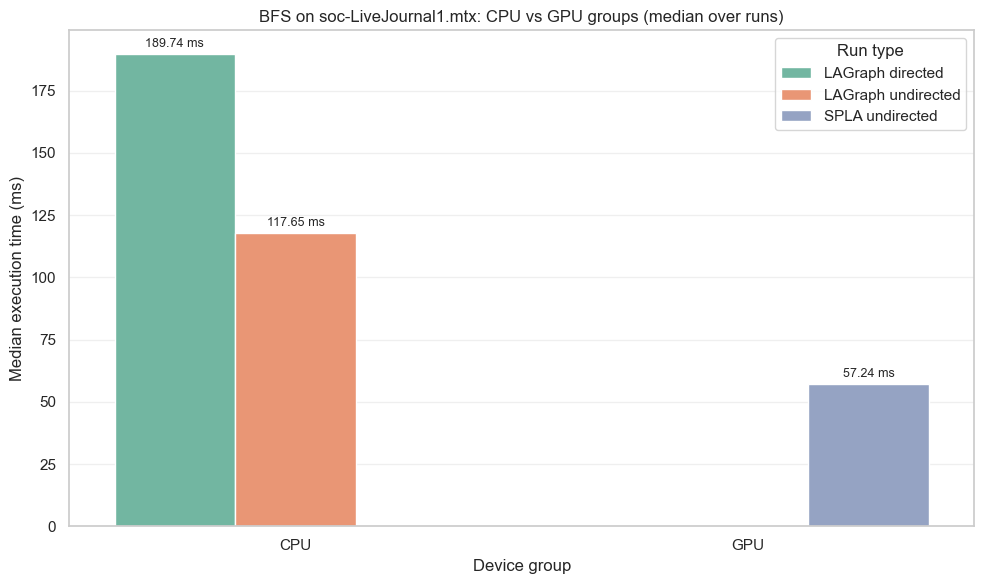

In [5]:
target_graph = 'soc-LiveJournal1.mtx'
plot_df = df_bfs[df_bfs['Graph'] == target_graph].copy()

# 1. Исправляем маппинг (убедитесь, что имена совпадают с hue_order далее)
plot_df['Variant'] = plot_df['Library'].replace({
    'SPLA': 'SPLA undirected',
    'LAGraph-Normal': 'LAGraph directed',
    'LAGraph-Sym': 'LAGraph undirected'
})

# 2. Проверка: убедитесь, что у SPLA стоит Device='GPU'
# Если в CSV для SPLA пусто в Device, заполним:
plot_df.loc[plot_df['Library'] == 'SPLA', 'Device'] = 'GPU'

summary_device = (
    plot_df
    .groupby(['Device', 'Variant'], as_index=False)['Time_ms']
    .median()
    .rename(columns={'Time_ms': 'Median_ms'})
)

plt.figure(figsize=(10, 6))
# 3. Исправляем hue_order (названия должны быть ТАКИМИ ЖЕ как в Variant)
ax = sns.barplot(
    data=summary_device,
    x='Device',
    y='Median_ms',
    hue='Variant',
    order=['CPU', 'GPU'],
    hue_order=['LAGraph directed', 'LAGraph undirected', 'SPLA undirected'], # ИСПРАВЛЕНО ЗДЕСЬ
    palette='Set2'
)

# Добавляем аннотации
for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(
            f'{h:.2f} ms',
            (p.get_x() + p.get_width() / 2, h),w
            ha='center', va='bottom', fontsize=9, xytext=(0, 3),
            textcoords='offset points'
        )

plt.title(f'BFS on {target_graph}: CPU vs GPU groups (median over runs)')
plt.ylabel('Median execution time (ms)')
plt.xlabel('Device group')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Run type')
plt.tight_layout()
plt.savefig("bfs/jl_mean_time.png")
plt.show()

Normality checks (Shapiro-Wilk) for raw runs in graph 3:
  LiveJournal | LAGraph directed (CPU): p=0.03947 -> not normal (n=30)
  LiveJournal | LAGraph undirected (CPU): p=0.00418 -> not normal (n=30)
  LiveJournal | SPLA directed (GPU): p=0.00000 -> not normal (n=30)
  patents | LAGraph directed (CPU): p=0.00618 -> not normal (n=30)
  patents | LAGraph undirected (CPU): p=0.00000 -> not normal (n=30)
  patents | SPLA directed (GPU): p=0.00000 -> not normal (n=30)


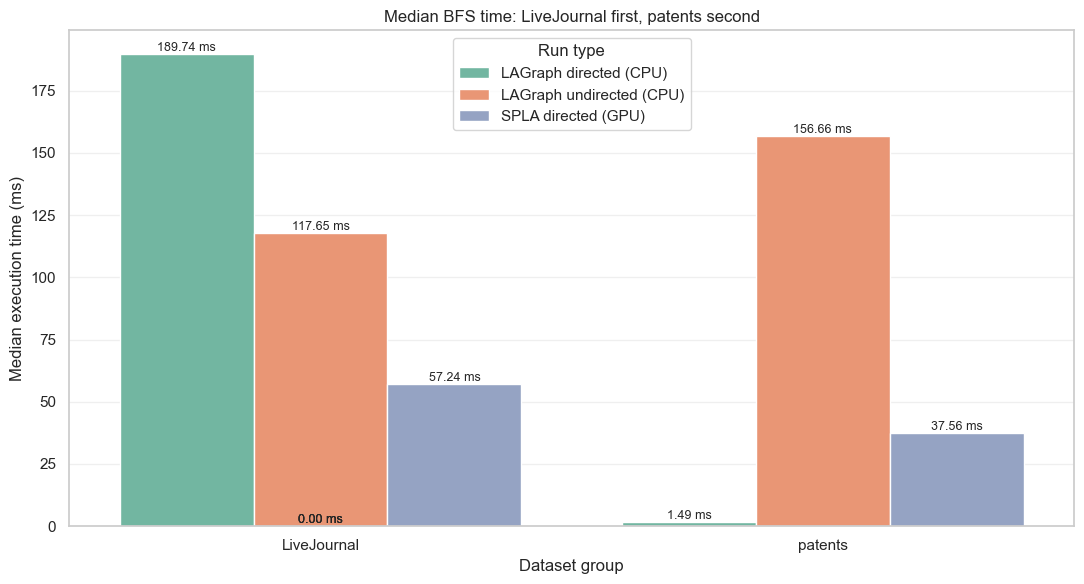

In [125]:
sns.set_theme(style="whitegrid")

base_df = df[df['Graph'].isin(['soc-LiveJournal1.mtx', 'patents.mtx'])].copy()

base_df['GraphGroup'] = base_df['Graph'].map({
    'soc-LiveJournal1.mtx': 'LiveJournal',
    'patents.mtx': 'patents'
})

variant_map = {
    'LAGraph-Sym': 'LAGraph undirected (CPU)',
    'LAGraph-Normal': 'LAGraph directed (CPU)',
    'SPLA': 'SPLA directed (GPU)'
}
base_df['Variant'] = base_df['Library'].map(variant_map)

plot_df = base_df[base_df['Variant'].notna()].copy()

summary = (
    plot_df
    .groupby(['GraphGroup', 'Variant'], as_index=False)['Time_ms']
    .median()
    .rename(columns={'Time_ms': 'Median_ms'})
)

print('Normality checks (Shapiro-Wilk) for raw runs in graph 3:')
for (graph_group, variant), g in plot_df.groupby(['GraphGroup', 'Variant']):
    sample = g['Time_ms'].dropna()
    if len(sample) >= 3:
        stat, p = stats.shapiro(sample)
        verdict = 'normal' if p > 0.05 else 'not normal'
        print(f'  {graph_group} | {variant}: p={p:.5f} -> {verdict} (n={len(sample)})')
    else:
        print(f'  {graph_group} | {variant}: n={len(sample)} (too small for Shapiro)')

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=summary,
    x='GraphGroup',
    y='Median_ms',
    hue='Variant',
    order=['LiveJournal', 'patents'],
    hue_order=['LAGraph directed (CPU)', 'LAGraph undirected (CPU)', 'SPLA directed (GPU)'],
    palette='Set2'
)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(
            f'{h:.2f} ms',
            (p.get_x() + p.get_width() / 2, h),
            ha='center', va='bottom', fontsize=9
        )

plt.title('Median BFS time: LiveJournal first, patents second')
plt.ylabel('Median execution time (ms)')
plt.xlabel('Dataset group')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Run type')
plt.tight_layout()
plt.savefig("bfs/all_mean_time.png")
plt.show()

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_24381/647022821.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='viridis')


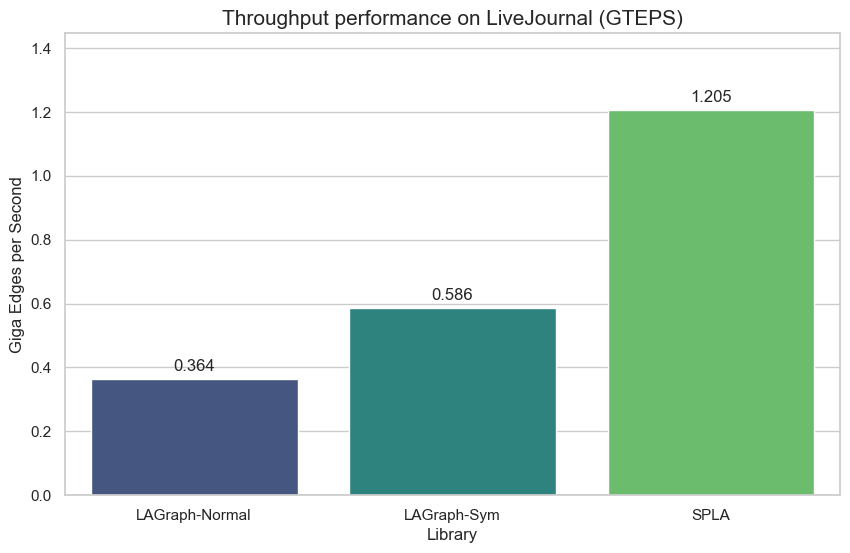

Performance LAGraph-Normal: 0.364 GTEPS
Performance LAGraph-Sym: 0.586 GTEPS
Performance SPLA: 1.205 GTEPS


In [128]:
edges_lj = {
    'soc-LiveJournal1.mtx': 68993773
}

gteps_df = base_df[base_df['Graph'] == 'soc-LiveJournal1.mtx'].copy()

gteps_df = gteps_df.groupby(['Graph', 'Library'])['Time_ms'].median().reset_index()

gteps_df['GTEPS'] = gteps_df.apply(lambda x: edges_lj[x['Graph']] / (x['Time_ms'] * 1e6), axis=1)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=gteps_df, x='Library', y='GTEPS', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Throughput performance on LiveJournal (GTEPS)', fontsize=15)
plt.ylabel('Giga Edges per Second', fontsize=12)
plt.xlabel('Library', fontsize=12)
plt.ylim(0, gteps_df['GTEPS'].max() * 1.2)
plt.savefig("bfs/all_gteps.png")
plt.show()

for index, row in gteps_df.iterrows():
    print(f"Performance {row['Library']}: {row['GTEPS']:.3f} GTEPS")

In [1]:
import csv
import subprocess
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

RUN_NUM = 5


def detect_repo_root() -> Path:
    cur = Path.cwd().resolve()
    for candidate in [cur] + list(cur.parents):
        if (candidate / "datasets").exists() and (candidate / "bfs_runner.c").exists():
            return candidate
    raise RuntimeError("Could not detect repository root")


ROOT = detect_repo_root()
RESULT_DIR = ROOT / "results" / "bfs"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = [
    ROOT / "datasets" / "soc-LiveJournal1.mtx",
    ROOT / "datasets" / "patents.mtx",
]

LAGRAPH_EXE = ROOT / "bfs_runner"
SPLA_EXE = ROOT / "spla" / "build" / "bfs"
CSV_PATH = RESULT_DIR / "bfs_mode_results_run5.csv"


def run_cmd(cmd):
    return subprocess.run(cmd, capture_output=True, text=True, check=True).stdout


def parse_lagraph_ms(stdout: str) -> float:
    for line in stdout.splitlines():
        if line.startswith("cpu(s):"):
            return float(line.split(":", 1)[1].strip()) * 1000.0
    raise RuntimeError("cpu(s) line not found")


def parse_spla_gpu_times(stdout: str):
    for line in stdout.splitlines():
        if line.startswith("gpu(ms):"):
            payload = line.replace("gpu(ms):", "").replace(" ", "").strip().strip(",")
            return [float(x) for x in payload.split(",") if x]
    raise RuntimeError("gpu(ms) line not found")


# Compile LAGraph runner (reproducible notebook execution)
omp_path = subprocess.check_output(["brew", "--prefix", "libomp"], text=True).strip()
compile_cmd = [
    "clang", "-O3", str(ROOT / "bfs_runner.c"), "-o", str(LAGRAPH_EXE),
    "-Xpreprocessor", "-fopenmp",
    "-I", f"{omp_path}/include",
    "-I", str(ROOT / "LAGraph" / "include"),
    "-I", "/usr/local/include/suitesparse",
    str(ROOT / "LAGraph" / "build" / "src" / "libLAGraph.a"),
    "-L", f"{omp_path}/lib",
    "-L", "/usr/local/lib",
    "-lgraphblas", "-lomp",
    "-Wl,-rpath,/usr/local/lib",
    f"-Wl,-rpath,{omp_path}/lib",
]
subprocess.run(compile_cmd, check=True)

rows = []
for dataset in DATASETS:
    if not dataset.exists():
        continue
    graph = dataset.name

    # LAGraph directed: kind=1, sym=0
    for i in range(1, RUN_NUM + 1):
        out = run_cmd([str(LAGRAPH_EXE), str(dataset), "1", "0"])
        rows.append([graph, "LAGraph directed", "directed", i, parse_lagraph_ms(out)])

    # LAGraph undirected: kind=0, sym=1
    for i in range(1, RUN_NUM + 1):
        out = run_cmd([str(LAGRAPH_EXE), str(dataset), "0", "1"])
        rows.append([graph, "LAGraph undirected", "undirected", i, parse_lagraph_ms(out)])

    # SpLA directed
    out = run_cmd([
        str(SPLA_EXE),
        f"--mtxpath={dataset}",
        f"--niters={RUN_NUM}",
        "--source=0",
        "--run-ref=false",
        "--run-cpu=false",
        "--run-gpu=true",
        "--undirected=false",
    ])
    for i, t in enumerate(parse_spla_gpu_times(out)[:RUN_NUM], start=1):
        rows.append([graph, "SpLA directed", "directed", i, t])

    # SpLA undirected
    out = run_cmd([
        str(SPLA_EXE),
        f"--mtxpath={dataset}",
        f"--niters={RUN_NUM}",
        "--source=0",
        "--run-ref=false",
        "--run-cpu=false",
        "--run-gpu=true",
        "--undirected=true",
    ])
    for i, t in enumerate(parse_spla_gpu_times(out)[:RUN_NUM], start=1):
        rows.append([graph, "SpLA undirected", "undirected", i, t])

with CSV_PATH.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Graph", "LibraryMode", "Mode", "Iteration", "Time_ms"])
    writer.writerows(rows)


df = pd.DataFrame(rows, columns=["Graph", "LibraryMode", "Mode", "Iteration", "Time_ms"])

# ВАЖНО: отбрасываем первый ран и считаем медиану по оставшимся
plot_df = df[df["Iteration"] > 1].copy()
median_df = (
    plot_df.groupby(["Graph", "LibraryMode"], as_index=False)["Time_ms"]
    .median()
    .rename(columns={"Time_ms": "Median_ms"})
)

print(f"Saved raw run data to: {CSV_PATH}")
print("Median table (Iteration > 1):")
print(median_df)


Saved raw run data to: /Users/qruty/prog/graphs/results/bfs/bfs_mode_results_run5.csv
Median table (Iteration > 1):
                  Graph         LibraryMode  Median_ms
0           patents.mtx    LAGraph directed     1.7260
1           patents.mtx  LAGraph undirected   164.9705
2           patents.mtx       SpLA directed    36.6120
3           patents.mtx     SpLA undirected    37.2585
4  soc-LiveJournal1.mtx    LAGraph directed   200.8705
5  soc-LiveJournal1.mtx  LAGraph undirected   122.5390
6  soc-LiveJournal1.mtx       SpLA directed    57.9260
7  soc-LiveJournal1.mtx     SpLA undirected    57.2690


/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_89852/1563125511.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lj, x="LibraryMode", y="Median_ms", palette="Set2")


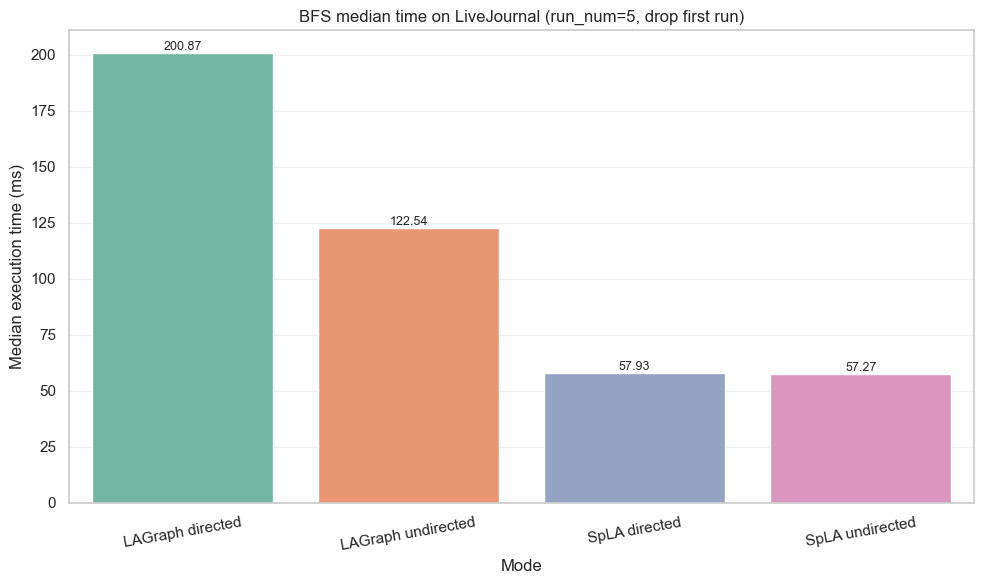

In [2]:
# График 1: только LiveJournal, 4 чарта на одном полотне
order_modes = [
    "LAGraph directed",
    "LAGraph undirected",
    "SpLA directed",
    "SpLA undirected",
]

lj = median_df[median_df["Graph"] == "soc-LiveJournal1.mtx"].copy()
lj["LibraryMode"] = pd.Categorical(lj["LibraryMode"], categories=order_modes, ordered=True)
lj = lj.sort_values("LibraryMode")

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=lj, x="LibraryMode", y="Median_ms", palette="Set2")

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=9)

plt.title("BFS median time on LiveJournal (run_num=5, drop first run)")
plt.ylabel("Median execution time (ms)")
plt.xlabel("Mode")
plt.xticks(rotation=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "bfs_modes_livejournal_run5.png", dpi=150)
plt.show()


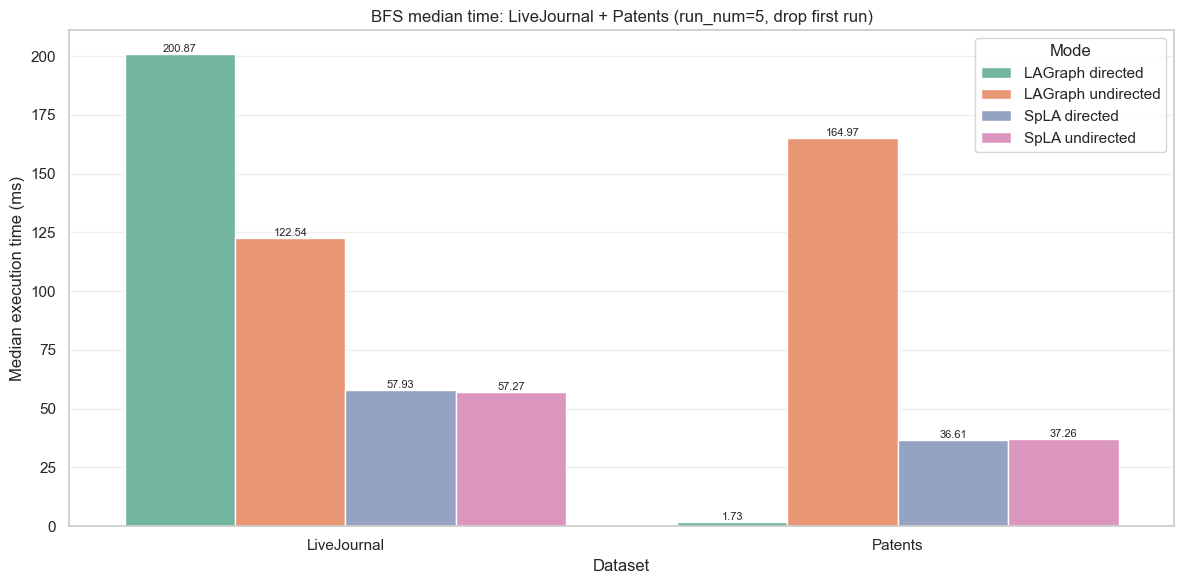

/var/folders/hk/lfdr9_h57c9d_kj4145634h40000gn/T/ipykernel_89852/1653643498.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=lj_gteps, x="LibraryMode", y="GTEPS", palette="viridis")


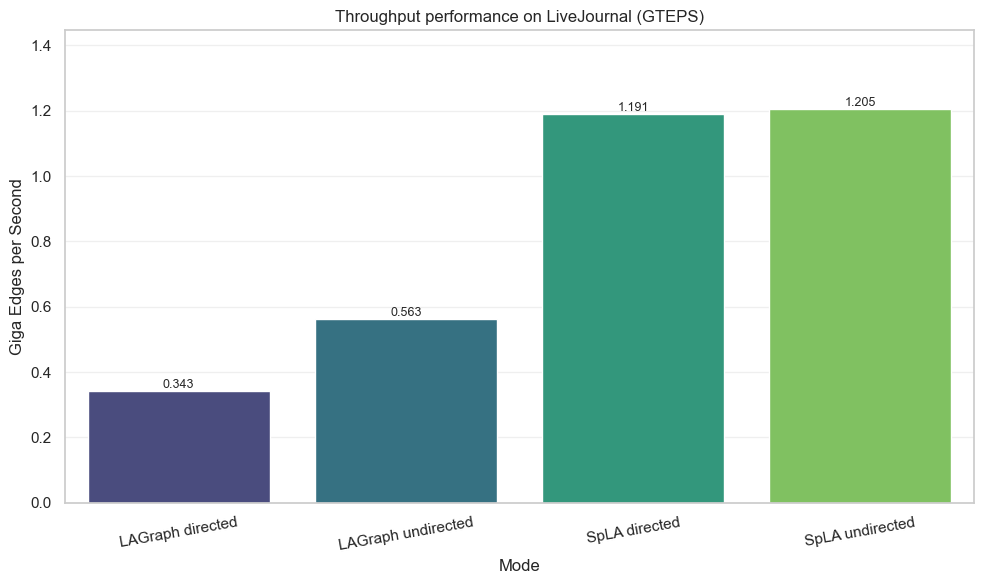

In [3]:
# График 2: LiveJournal + Patents, 4 режима
both = median_df.copy()

name_map = {
    "soc-LiveJournal1.mtx": "LiveJournal",
    "patents.mtx": "Patents",
}
both = both[both["Graph"].isin(name_map.keys())].copy()
both["GraphName"] = both["Graph"].map(name_map)
both["LibraryMode"] = pd.Categorical(both["LibraryMode"], categories=order_modes, ordered=True)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=both,
    x="GraphName",
    y="Median_ms",
    hue="LibraryMode",
    order=["LiveJournal", "Patents"],
    hue_order=order_modes,
    palette="Set2",
)

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h) and h > 0:
        ax.annotate(f"{h:.2f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=8)

plt.title("BFS median time: LiveJournal + Patents (run_num=5, drop first run)")
plt.ylabel("Median execution time (ms)")
plt.xlabel("Dataset")
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Mode")
plt.tight_layout()
plt.savefig(RESULT_DIR / "bfs_modes_livejournal_patents_run5.png", dpi=150)
plt.show()

# Оставляем throughput-график для LiveJournal (в стиле презентации)
edges_lj = 68993773
lj_gteps = both[both["GraphName"] == "LiveJournal"].copy()
lj_gteps["GTEPS"] = edges_lj / (lj_gteps["Median_ms"] * 1e6)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=lj_gteps, x="LibraryMode", y="GTEPS", palette="viridis")

for p in ax.patches:
    h = p.get_height()
    if pd.notna(h):
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2, h), ha="center", va="bottom", fontsize=9)

plt.title("Throughput performance on LiveJournal (GTEPS)")
plt.ylabel("Giga Edges per Second")
plt.xlabel("Mode")
plt.xticks(rotation=10)
plt.ylim(0, lj_gteps["GTEPS"].max() * 1.2)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / "all_gteps_livejournal_run5.png", dpi=150)
plt.show()


In [4]:
# Готовый текстовый вывод для презентации
pivot = median_df.pivot(index="Graph", columns="LibraryMode", values="Median_ms")

print("=== BFS presentation summary (run_num=5, median, first run dropped) ===")
for graph in ["soc-LiveJournal1.mtx", "patents.mtx"]:
    if graph not in pivot.index:
        continue

    row = pivot.loc[graph]
    g_name = "LiveJournal" if graph == "soc-LiveJournal1.mtx" else "Patents"

    print(f"\nDataset: {g_name}")
    for mode in ["LAGraph directed", "LAGraph undirected", "SpLA directed", "SpLA undirected"]:
        if mode in row and pd.notna(row[mode]):
            print(f"  {mode}: {row[mode]:.2f} ms")

    if "LAGraph directed" in row and "LAGraph undirected" in row:
        delta_lg = (row["LAGraph undirected"] / row["LAGraph directed"] - 1.0) * 100.0
        sign_lg = "+" if delta_lg >= 0 else ""
        print(f"  LAGraph undir vs dir: {sign_lg}{delta_lg:.1f}%")

    if "SpLA directed" in row and "SpLA undirected" in row:
        delta_sp = (row["SpLA undirected"] / row["SpLA directed"] - 1.0) * 100.0
        sign_sp = "+" if delta_sp >= 0 else ""
        print(f"  SpLA undir vs dir: {sign_sp}{delta_sp:.1f}%")

print("\nBefore fix in SpLA: --undirected was passed in benchmark scripts but bfs example did not apply it when building adjacency.")
print("After fix in SpLA: bfs now explicitly applies --undirected by adding reverse edges and prints graph mode in runtime logs.")
print("Current state: directed/undirected comparison in BFS is now methodologically valid for both LAGraph and SpLA.")


=== BFS presentation summary (run_num=5, median, first run dropped) ===

Dataset: LiveJournal
  LAGraph directed: 200.87 ms
  LAGraph undirected: 122.54 ms
  SpLA directed: 57.93 ms
  SpLA undirected: 57.27 ms
  LAGraph undir vs dir: -39.0%
  SpLA undir vs dir: -1.1%

Dataset: Patents
  LAGraph directed: 1.73 ms
  LAGraph undirected: 164.97 ms
  SpLA directed: 36.61 ms
  SpLA undirected: 37.26 ms
  LAGraph undir vs dir: +9458.0%
  SpLA undir vs dir: +1.8%

Before fix in SpLA: --undirected was passed in benchmark scripts but bfs example did not apply it when building adjacency.
After fix in SpLA: bfs now explicitly applies --undirected by adding reverse edges and prints graph mode in runtime logs.
Current state: directed/undirected comparison in BFS is now methodologically valid for both LAGraph and SpLA.
